Shane Rodgers
MSDS 696 Data Science Practium II 2025   April 24th, 2025  V2

 # Colorado Legal Service Sales Predictor
 (Working Version 2)
This notebook demonstrates a simple machine learning approach to identify potential clients for subscription legal plans 
using data science and machine learning techniques to predict which types of legal services a potential client may need 
based on demographic characteristics and personal circumstances. 

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import os

# Set up matplotlib for inline display
%matplotlib inline


In [77]:
import os

# Get and print the current working directory
current_directory = os.getcwd()
print("Current working directory:", current_directory)

Current working directory: /Users/shanerodgers


In [79]:
def load_data(filepath):
    """Load the dataset from Excel and show basic information"""
    # Check file extension
    if filepath.endswith('.xlsx') or filepath.endswith('.xls'):
        # Load data from Excel
        df = pd.read_excel(filepath)
    else:
        # Load data from CSV (keeping for backward compatibility)
        df = pd.read_csv(filepath)
    
    # Display basic information
    print("Dataset shape:", df.shape)
    print("\nFirst 5 rows:")
    print(df.head())
    
    return df

In [81]:
df = load_data('/Users/shanerodgers/Desktop/simplified_legal_needs_data.xlsx')

Dataset shape: (1000, 6)

First 5 rows:
   age income_level marital_status  business_owner  home_owner  \
0   50       Medium         Single           False       False   
1   38          Low         Single           False       False   
2   28         High         Single            True        True   
3   27          Low         Single            True        True   
4   27         High        Married            True        True   

        legal_need  
0  Personal Injury  
1  Personal Injury  
2      Real Estate  
3  Estate Planning  
4  Estate Planning  


In [83]:
# Data Visualization Function
def visualize_data(df):
    """Create simple visualizations to understand the data"""
    print("\n--- Data Visualization (Statistical Tool #1) ---")
    
    # Create a directory for visualizations
    if not os.path.exists('visualizations'):
        os.makedirs('visualizations')
    
    # 1. Bar chart of legal needs distribution
    plt.figure(figsize=(10, 6))
    legal_needs_counts = df['legal_need'].value_counts()
    ax = sns.barplot(x=legal_needs_counts.index, y=legal_needs_counts.values)
    plt.title('Distribution of Legal Needs')
    plt.xlabel('Legal Need Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    for i, v in enumerate(legal_needs_counts.values):
        ax.text(i, v + 0.5, str(v), ha='center')
    plt.tight_layout()
    plt.savefig('visualizations/legal_needs_distribution.png')
    plt.show()  # Add this to display in Jupyter
    
    # 2. Age distribution by legal need
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='legal_need', y='age', data=df)
    plt.title('Age Distribution by Legal Need')
    plt.xlabel('Legal Need Category')
    plt.ylabel('Age')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('visualizations/age_by_legal_need.png')
    plt.show()  # Add this to display in Jupyter
    
    # 3. Business ownership by legal need (simple stacked bar)
    plt.figure(figsize=(10, 6))
    pd.crosstab(df['business_owner'], df['legal_need']).plot(kind='bar', stacked=True)
    plt.title('Business Ownership by Legal Need')
    plt.xlabel('Business Owner')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.legend(title='Legal Need')
    plt.tight_layout()
    plt.savefig('visualizations/business_by_legal_need.png')
    plt.show()  # Add this to display in Jupyter
    
    print("Created 3 visualizations to help understand the data patterns")

In [85]:
# Modified preprocessing function to handle NaN values
def preprocess_data(df):
    """Prepare the data for machine learning and handle missing values"""
    # First, check for NaN values
    print("Checking for missing values in each column:")
    print(df.isna().sum())
    
    # Define features and target
    X = df.drop('legal_need', axis=1)
    y = df['legal_need']
    
    # Fill missing values in target variable (if any)
    if y.isna().any():
        print("\nFilling missing values in target variable...")
        # For classification tasks, we can replace NaNs with the most common category
        y = y.fillna(y.mode()[0])
    
    # Identify numerical and categorical columns
    numerical_cols = ['age']
    categorical_cols = ['income_level', 'marital_status', 'business_owner', 'home_owner']
    
    # Create preprocessing steps with imputation
    # This handles both numerical scaling, categorical encoding, and missing values
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),  # Handle missing numerical values
                ('scaler', StandardScaler())
            ]), numerical_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing categorical values
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
            ]), categorical_cols)
        ])
    
    print("\nPreprocessing applied with imputation for missing values")
    return X, y, preprocessor

In [87]:
# Model Building Function
def build_model(X, y, preprocessor):
    """Build and evaluate a Random Forest model"""
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Create the model pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=50, random_state=42))
    ])
    
    # Train the model
    print("\nTraining the model...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nModel Accuracy: {accuracy:.2f}")
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Create confusion matrix visualization
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y.unique()), 
                yticklabels=sorted(y.unique()))
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Legal Need')
    plt.xlabel('Predicted Legal Need')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('visualizations/confusion_matrix.png')
    plt.show()  # Add this to display in Jupyter
    
    return model

In [89]:
#Feature Importance Analysis Function
def analyze_features(model, X):
    """Analyze which features are most important for prediction"""
    print("\n--- Feature Importance Analysis (Statistical Tool #2) ---")
    
    # Get feature names after preprocessing
    feature_names = []
    
    # Add numerical feature names
    feature_names.extend(['age'])
    
    # Add encoded categorical feature names
    feature_names.extend(['income_level_Low', 'income_level_Medium', 'income_level_High'])
    feature_names.extend(['marital_status_Divorced', 'marital_status_Married', 'marital_status_Single'])
    feature_names.extend(['business_owner_False', 'business_owner_True'])
    feature_names.extend(['home_owner_False', 'home_owner_True'])
    
    # Get feature importances from model
    importances = model['classifier'].feature_importances_
    
    # Create a list of tuples with feature names and importances
    feature_importance = list(zip(feature_names, importances))
    feature_importance.sort(key=lambda x: x[1], reverse=True)
    
    # Print feature importances
    print("\nFeature Importances:")
    for feature, importance in feature_importance:
        print(f"{feature}: {importance:.4f}")
    
    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    features, importance_values = zip(*feature_importance)
    sns.barplot(x=list(importance_values), y=list(features))
    plt.title('Feature Importance for Legal Need Prediction')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('visualizations/feature_importance.png')
    plt.show()  # Add this to display in Jupyter
    
    return feature_importance

In [91]:
#Prediction Function
def make_prediction(model, input_data):
    """Make a prediction for a sample client"""
    # Convert input to DataFrame if it's not already
    if not isinstance(input_data, pd.DataFrame):
        input_data = pd.DataFrame([input_data])
    
    # Make prediction
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    
    # Get class labels
    classes = model.classes_
    
    # Create a dictionary of probabilities
    prob_dict = {class_label: prob for class_label, prob in zip(classes, probabilities)}
    
    # Sort by probability
    sorted_probs = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)
    
    return prediction, sorted_probs

In [93]:
#1 Load Data
print("===== SIMPLIFIED LEGAL SERVICE NEED PREDICTOR =====")
print("\n1. LOADING DATA")
df = load_data('/Users/shanerodgers/Desktop/simplified_legal_needs_data.xlsx')

===== SIMPLIFIED LEGAL SERVICE NEED PREDICTOR =====

1. LOADING DATA
Dataset shape: (1000, 6)

First 5 rows:
   age income_level marital_status  business_owner  home_owner  \
0   50       Medium         Single           False       False   
1   38          Low         Single           False       False   
2   28         High         Single            True        True   
3   27          Low         Single            True        True   
4   27         High        Married            True        True   

        legal_need  
0  Personal Injury  
1  Personal Injury  
2      Real Estate  
3  Estate Planning  
4  Estate Planning  



2. VISUALIZING DATA PATTERNS

--- Data Visualization (Statistical Tool #1) ---


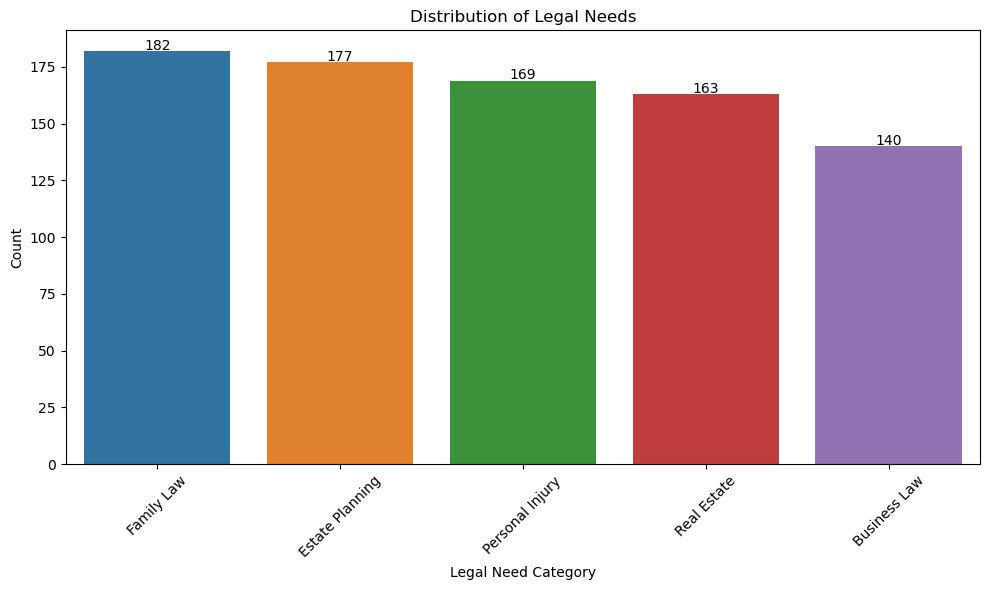

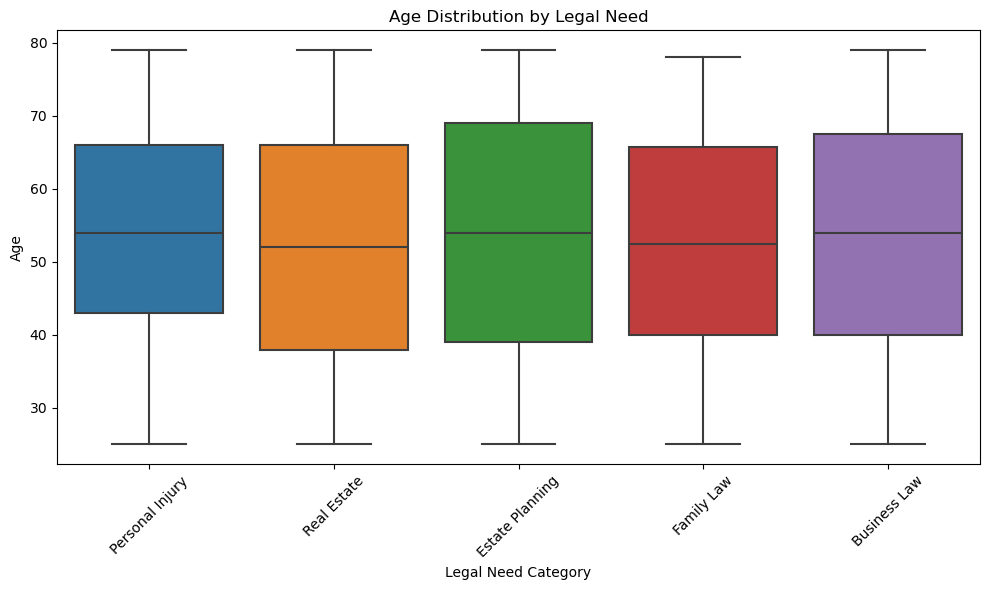

<Figure size 1000x600 with 0 Axes>

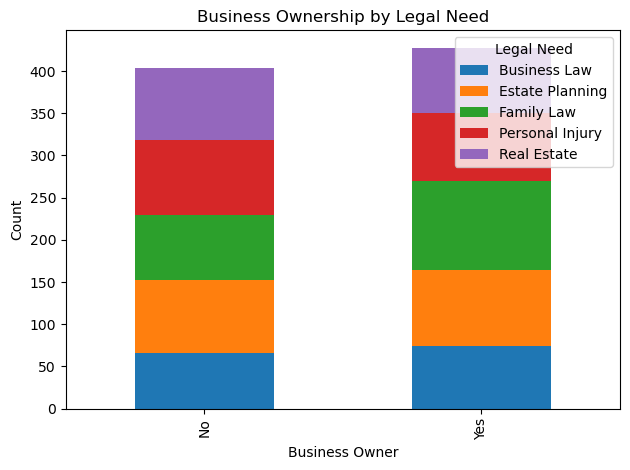

Created 3 visualizations to help understand the data patterns


In [95]:
#2 Visualize Data
print("\n2. VISUALIZING DATA PATTERNS")
visualize_data(df)

In [97]:
#3 Preprocess Data
print("\n3. PREPROCESSING DATA")
X, y, preprocessor = preprocess_data(df)
print(f"Features prepared: {X.shape[1]} input columns")


3. PREPROCESSING DATA
Checking for missing values in each column:
age                 0
income_level        0
marital_status      0
business_owner      0
home_owner          0
legal_need        169
dtype: int64

Filling missing values in target variable...

Preprocessing applied with imputation for missing values
Features prepared: 5 input columns



4. BUILDING MACHINE LEARNING MODEL

Training the model...

Model Accuracy: 0.22

Classification Report:
                 precision    recall  f1-score   support

   Business Law       0.10      0.10      0.10        41
Estate Planning       0.15      0.18      0.17        44
     Family Law       0.34      0.42      0.37        95
Personal Injury       0.21      0.13      0.16        67
    Real Estate       0.13      0.11      0.12        53

       accuracy                           0.22       300
      macro avg       0.19      0.19      0.18       300
   weighted avg       0.21      0.22      0.21       300



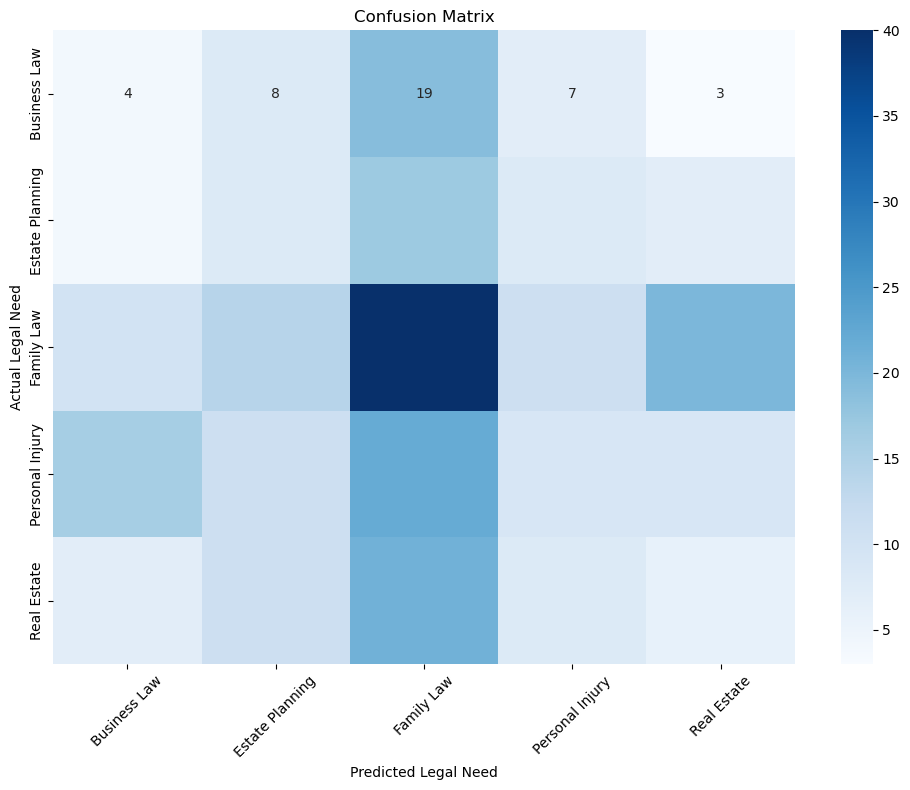

In [99]:
#4 Build and Evaluate Model
print("\n4. BUILDING MACHINE LEARNING MODEL")
model = build_model(X, y, preprocessor)


5. ANALYZING FEATURE IMPORTANCE

--- Feature Importance Analysis (Statistical Tool #2) ---

Feature Importances:
age: 0.8086
income_level_Medium: 0.0221
income_level_Low: 0.0220
income_level_High: 0.0219
home_owner_True: 0.0210
marital_status_Divorced: 0.0202
home_owner_False: 0.0199
marital_status_Single: 0.0184
marital_status_Married: 0.0181
business_owner_False: 0.0139
business_owner_True: 0.0138


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


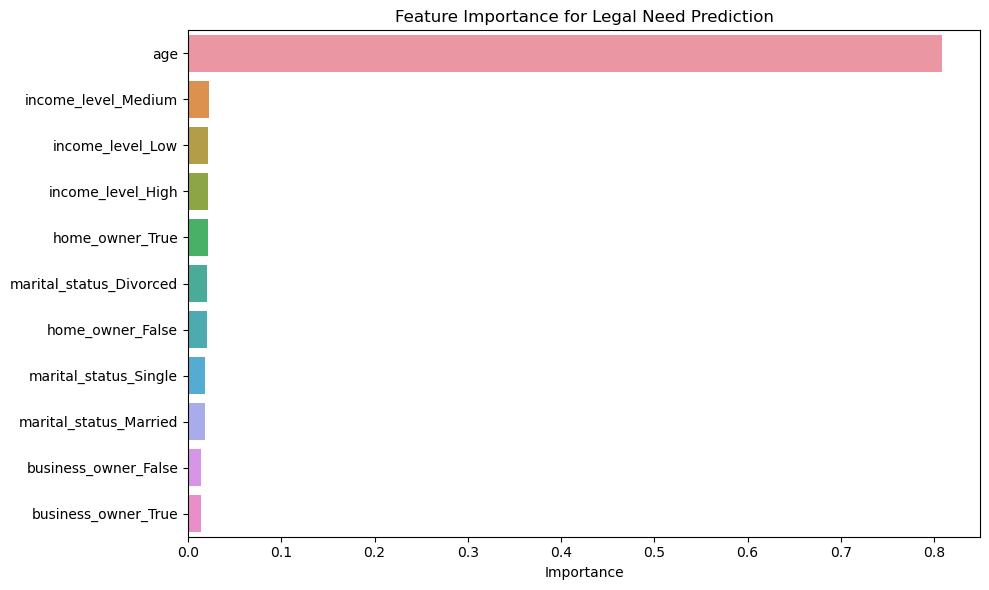

In [101]:
#5 Analyze Feature Importance
print("\n5. ANALYZING FEATURE IMPORTANCE")
feature_importance = analyze_features(model, X)

In [103]:
#6 Sample Prediction
print("\n6. EXAMPLE PREDICTION")
# Create a sample client
sample_client = {
    'age': 68,
    'income_level': 'High', 
    'marital_status': 'Married',
    'business_owner': True,
    'home_owner': True
}

# Convert to DataFrame
sample_df = pd.DataFrame([sample_client])

# Make prediction
prediction, probabilities = make_prediction(model, sample_df)

# Display results
print("\nSample Client Profile:")
for key, value in sample_client.items():
    print(f"  {key}: {value}")

print(f"\nPredicted Legal Need: {prediction}")
print("\nPrediction Probabilities:")
for need, prob in probabilities:
    print(f"  {need}: {prob:.4f}")

print("\n===== PROJECT COMPLETED SUCCESSFULLY =====")


6. EXAMPLE PREDICTION

Sample Client Profile:
  age: 68
  income_level: High
  marital_status: Married
  business_owner: True
  home_owner: True

Predicted Legal Need: Family Law

Prediction Probabilities:
  Family Law: 0.9200
  Estate Planning: 0.0400
  Real Estate: 0.0400
  Business Law: 0.0000
  Personal Injury: 0.0000

===== PROJECT COMPLETED SUCCESSFULLY =====
